<a href="https://colab.research.google.com/github/sameersahu18/cnn01mnist_numeric/blob/main/CNN01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Flatten

from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dropout

from tensorflow.keras.utils import to_categorical

In [ ]:
df =pd.read_csv('mnist_train.csv')
df_test=pd.read_csv('mnist_test.csv')
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:

df = df.fillna(0)
df_test = df_test.fillna(0)

In [ ]:
df_test.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df.shape

(2865, 785)

In [ ]:
df.columns

Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5',
       'pixel6', 'pixel7', 'pixel8',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='object', length=785)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2865 entries, 0 to 2864
Columns: 785 entries, label to pixel783
dtypes: float64(52), int64(733)
memory usage: 17.2 MB


In [ ]:
df.isnull().sum()

,0
label,0
pixel0,0
pixel1,0
pixel2,0
pixel3,0
...,...
pixel779,0
pixel780,0
pixel781,0
pixel782,0


In [ ]:
# Original training data features and labels
X = df.drop("label", axis=1).values
y = df["label"].values

# Split df into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# X_test remains the original df_test for final evaluation (without labels for now)
X_test = df_test.values



In [ ]:
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [ ]:
X_train_img = X_train.reshape(-1, 28, 28)
X_val_img = X_val.reshape(-1, 28, 28)
X_test_img = X_test.reshape(-1, 28, 28)

In [ ]:
y_train_cat = to_categorical(y_train, 10)
y_val_cat = to_categorical(y_val, 10)

In [ ]:
perceptron=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10, activation="softmax")
])

In [ ]:
perceptron.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])

In [ ]:
history_percp = perceptron.fit(X_train_img, y_train_cat, epochs=5, batch_size=32, validation_data=(X_val_img, y_val_cat), verbose=1)

Epoch 1/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3770 - loss: 1.9965 - val_accuracy: 0.5724 - val_loss: 1.7232
Epoch 2/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6588 - loss: 1.5285 - val_accuracy: 0.7051 - val_loss: 1.3711
Epoch 3/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7417 - loss: 1.2541 - val_accuracy: 0.7731 - val_loss: 1.1543
Epoch 4/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7740 - loss: 1.0825 - val_accuracy: 0.7941 - val_loss: 1.0101
Epoch 5/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7989 - loss: 0.9647 - val_accuracy: 0.8080 - val_loss: 0.9087


In [ ]:
acc_percp = perceptron.evaluate(X_val_img, y_val_cat, verbose=0)[1]
acc_percp

0.8080279231071472

In [ ]:
ann=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation="relu"),
    Dense(64,activation="relu"),
    Dense(10,activation="softmax")
])

In [ ]:
ann.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [ ]:
history_ann = ann.fit(X_train_img, y_train_cat, epochs=5, batch_size=32, validation_data=(X_val_img, y_val_cat), verbose=1)


Epoch 1/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7190 - loss: 1.0553 - val_accuracy: 0.8796 - val_loss: 0.4618
Epoch 2/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8940 - loss: 0.3766 - val_accuracy: 0.8743 - val_loss: 0.3955
Epoch 3/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9250 - loss: 0.2679 - val_accuracy: 0.9145 - val_loss: 0.3003
Epoch 4/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9572 - loss: 0.1861 - val_accuracy: 0.9232 - val_loss: 0.2559
Epoch 5/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9677 - loss: 0.1388 - val_accuracy: 0.9319 - val_loss: 0.2352


In [ ]:
acc_ann = ann.evaluate(X_val_img, y_val_cat, verbose=0)[1]
acc_ann

0.9319371581077576

In [ ]:
X_train_cnn = X_train.reshape(-1, 28, 28,1)
X_test_cnn = X_val.reshape(-1, 28, 28, 1)


In [ ]:
cnn = Sequential([
    Conv2D(32, kernel_size=(3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation="relu"),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

In [ ]:
cnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [ ]:
history_cnn = cnn.fit(X_train_cnn, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_cnn, y_val_cat), verbose=1)


Epoch 1/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.5807 - loss: 1.2807 - val_accuracy: 0.8848 - val_loss: 0.4191
Epoch 2/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8490 - loss: 0.5082 - val_accuracy: 0.9442 - val_loss: 0.2077
Epoch 3/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9014 - loss: 0.3298 - val_accuracy: 0.9372 - val_loss: 0.1980
Epoch 4/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9241 - loss: 0.2685 - val_accuracy: 0.9616 - val_loss: 0.1317
Epoch 5/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9498 - loss: 0.1936 - val_accuracy: 0.9651 - val_loss: 0.1284


In [ ]:
acc_cnn = cnn.evaluate(X_test_cnn, y_val_cat, verbose=0)[1]
acc_cnn

0.9650959968566895

In [ ]:
def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()

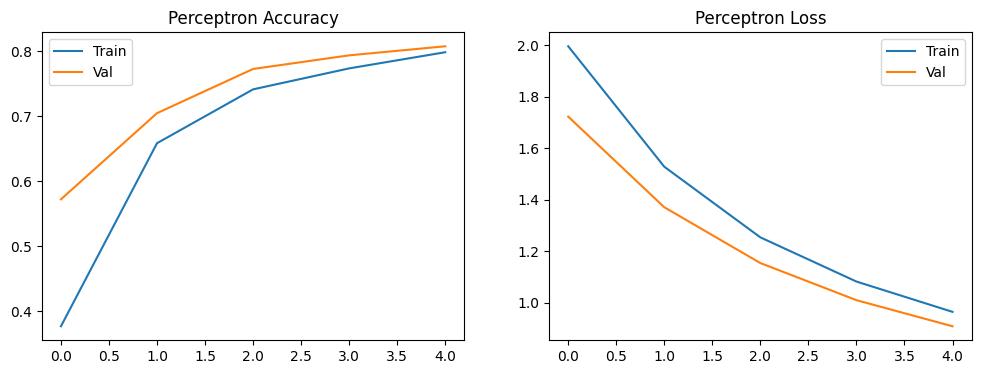

In [ ]:
plot_training(history_percp, "Perceptron")